In [1]:
from functools import reduce

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import utils as ut

In [2]:
df_itc_all, dict_info = ut.load_itc_dataset("full")

In [3]:
df_itc_all.head()

,Unnamed: 0,right_time,right_val,left_time,left_val,att_check,condition,time_diff,sooner_time,relative_value_diff,absolute_value_diff,right_picked,sid,month,sid_continue,sid_unique
0,0,42,2.666667,21,0.666667,0,4,21,21,4.0,2.0,1,1,March,0.0,1
1,1,0,33.333333,50,133.333333,0,4,50,0,4.0,100.0,0,1,March,0.0,1
2,2,9,1500.000000,7,1000.000000,0,4,2,7,1.5,500.0,1,1,March,0.0,1
3,3,0,1000.000000,1,1100.000000,0,4,1,0,1.1,100.0,0,1,March,0.0,1
4,4,7,50.000000,11,55.000000,0,4,4,7,1.1,5.0,0,1,March,0.0,1


In [4]:
df_itc_all["r-l-v"] = df_itc_all["right_val"] - df_itc_all["left_val"]
df_itc_all["r-l-v-log"] = np.log(df_itc_all["right_val"]) - np.log(df_itc_all["left_val"])
df_itc_all["r-l-t"] = df_itc_all["right_time"] - df_itc_all["left_time"]
np.corrcoef(df_itc_all["r-l-v-log"], df_itc_all["r-l-t"])

array([[1.        , 0.47049261],
       [0.47049261, 1.        ]])

In [5]:
df_plt_v = df_itc_all.groupby("r-l-v-log")["right_picked"].agg(["mean", "count"]).reset_index()
df_plt_t = df_itc_all.groupby("r-l-t")["right_picked"].agg(["mean", "count"]).reset_index()

In [6]:
df_plt_vt = pd.concat([
    df_plt_v.melt(id_vars=["mean", "count"]),
    df_plt_t.melt(id_vars=["mean", "count"])
])

In [7]:
df_itc_all["v>0"] = df_itc_all["r-l-v"] > 0
df_itc_all["t>0"] = df_itc_all["r-l-t"] > 0

In [8]:
np.corrcoef(df_itc_all["v>0"], df_itc_all["t>0"])

array([[1., 1.],
       [1., 1.]])

In [9]:
df_itc_all.groupby("v>0")["right_picked"].mean()

v>0
False    0.175722
True     0.820740
Name: right_picked, dtype: float64

In [10]:
df_itc_all.groupby("t>0")["right_picked"].mean()

t>0
False    0.175722
True     0.820740
Name: right_picked, dtype: float64

/tmp/ipykernel_1611165/171584332.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), fontsize=12)
/tmp/ipykernel_1611165/171584332.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), fontsize=12)
/tmp/ipykernel_1611165/171584332.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), fontsize=12)


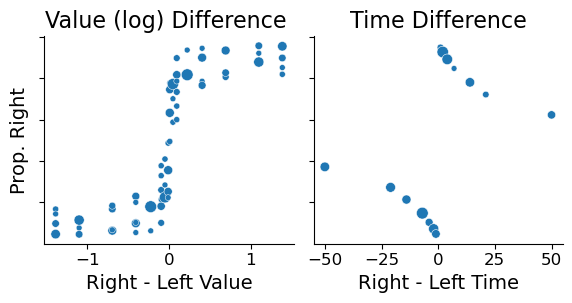

In [11]:
g = sns.FacetGrid(data=df_plt_vt, col="variable", col_wrap=2, sharex=False)
_ = g.map_dataframe(sns.scatterplot, x="value", y="mean", size="count")

titles = ["Value (log) Difference ", "Time Difference"]
xlabs = ["Right - Left Value", "Right - Left Time"]
for idx, ax in enumerate(g.axes.flat):
    ax.set_xlabel(xlabs[idx], fontsize=14)
    ax.set_ylabel("Prop. Right", fontsize=14)
    ax.set_title(titles[idx], fontsize=16)
    ax.set_xticklabels(ax.get_xticklabels(), fontsize=12)
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=12)

In [12]:
df_itc_all["r-l-t-bin"] = pd.cut(df_itc_all["r-l-t"], bins=[-51, -15, 0, 15, 51])

In [13]:
df_plt_both = df_itc_all.groupby(["r-l-v-log", "r-l-t-bin"])["right_picked"].agg(["mean", "count"]).reset_index()

/tmp/ipykernel_1611165/458380109.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_plt_both = df_itc_all.groupby(["r-l-v-log", "r-l-t-bin"])["right_picked"].agg(["mean", "count"]).reset_index()


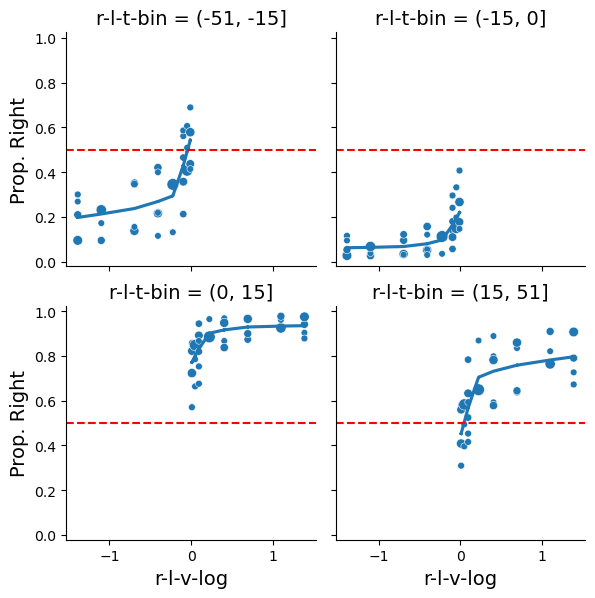

In [14]:
g = sns.FacetGrid(data=df_plt_both, col="r-l-t-bin", col_wrap=2)
g.map_dataframe(sns.scatterplot, x="r-l-v-log", y="mean", size="count")
_ = g.map_dataframe(sns.regplot, x="r-l-v-log", y="mean", scatter=False, lowess=True)

for idx, ax in enumerate(g.axes.flat):
    ax.set_xlabel(ax.get_xlabel(), fontsize=14)
    ax.set_ylabel("Prop. Right", fontsize=14)
    ax.set_title(ax.get_title(), fontsize=14)

    ax.axhline(y=.5, color="red", linestyle="--")


<Axes: >

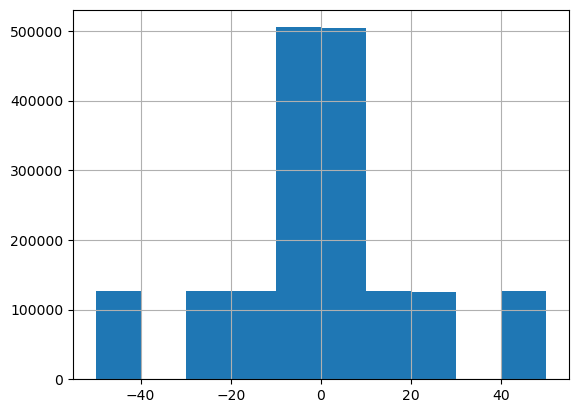

In [15]:
df_itc_all["r-l-t"].hist()

## Analyze Time Differences By Participant

In [16]:
pd.options.display.max_columns = 50

In [17]:
df_itc_all["sooner_picked"] = (((df_itc_all["right_picked"] == 1) & (df_itc_all["r-l-t"] < 0)) | ((df_itc_all["right_picked"] == 0) & (df_itc_all["r-l-t"] > 0))).astype(int)
df_itc_all["later_picked"] = (((df_itc_all["right_picked"] == 1) & (df_itc_all["r-l-t"] > 0)) | ((df_itc_all["right_picked"] == 0) & (df_itc_all["r-l-t"] < 0))).astype(int)

df_itc_all["moreval_picked"] = (((df_itc_all["right_picked"] == 1) & (df_itc_all["r-l-v"] > 0)) | ((df_itc_all["right_picked"] == 0) & (df_itc_all["r-l-v"] < 0))).astype(int)
df_itc_all["lessval_picked"] = (((df_itc_all["right_picked"] == 1) & (df_itc_all["r-l-v"] < 0)) | ((df_itc_all["right_picked"] == 0) & (df_itc_all["r-l-v"] > 0))).astype(int)


In [18]:
df_later_agg = df_itc_all.value_counts("sooner_picked").reset_index()
df_later_agg["prop"] = df_later_agg["count"] / df_later_agg["count"].sum()
df_later_agg

,sooner_picked,count,prop
0,0,1453450,0.82251
1,1,313640,0.17749


In [19]:
df_moreval_agg = df_itc_all.value_counts("moreval_picked").reset_index()
df_moreval_agg["prop"] = df_moreval_agg["count"] / df_moreval_agg["count"].sum()
df_moreval_agg

,moreval_picked,count,prop
0,1,1453450,0.82251
1,0,313640,0.17749


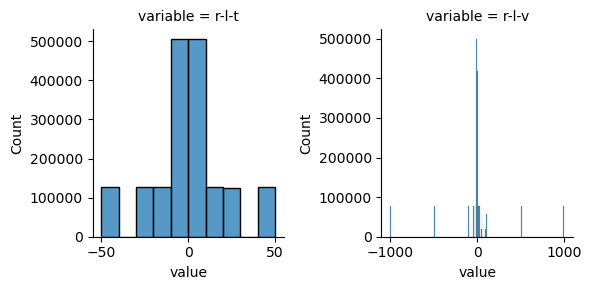

In [254]:
df_diffs = df_itc_all[["r-l-t", "r-l-v"]].melt()
g = sns.FacetGrid(data=df_diffs, col="variable", sharex=False, sharey=False)
g.map_dataframe(sns.histplot, x="value", binwidth=10)

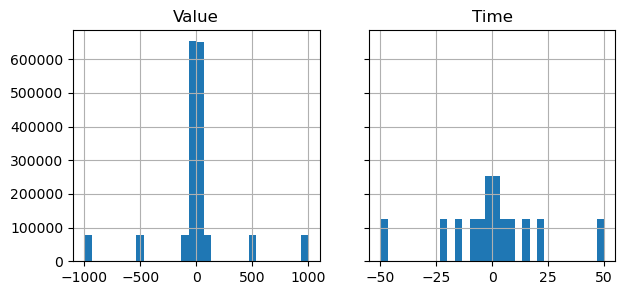

In [31]:
f, axes = plt.subplots(ncols=2, nrows=1, figsize=(7, 3), sharey=True)

l_titles = ["Value", "Time"]
for idx, subset in enumerate(["r-l-v", "r-l-t"]):
    axes[idx].hist(df_itc_all[subset], bins=30)
    axes[idx].set_title(l_titles[idx])
    axes[idx].grid(True)

In [128]:
df_itc_all["t-diff-bin-label"] = pd.qcut(df_itc_all["r-l-t"].abs(), 5)
df_itc_all["t-diff-bin-nr"] = pd.qcut(df_itc_all["r-l-t"].abs(), 5, labels=False)
df_itc_all["v-diff-bin-label"] = pd.qcut(df_itc_all["r-l-v"].abs(), 5)
df_itc_all["v-diff-bin-nr"] = pd.qcut(df_itc_all["r-l-v"].abs(), 5, labels=False)

In [129]:
np.corrcoef(df_itc_all[["absolute_value_diff", "relative_value_diff", "absolute_time_diff", "relative_time_diff"]].T).round(3)

array([[ 1.   ,  0.005,  0.001,  0.001],
       [ 0.005,  1.   , -0.   , -0.001],
       [ 0.001, -0.   ,  1.   ,  0.467],
       [ 0.001, -0.001,  0.467,  1.   ]])

In [130]:
df_sooner_sid = df_itc_all.groupby(["sid_unique", "t-diff-bin-nr"])["sooner_picked"].agg(["count", "mean", "std"]).reset_index()
df_more_sid = df_itc_all.groupby(["sid_unique", "v-diff-bin-nr"])["moreval_picked"].agg(["count", "mean", "std"]).reset_index()

In [297]:
np.random.seed(86)
sids_sample = df_itc_all["sid_unique"].drop_duplicates().sample(9)
#sids_sample = np.arange(16, 42, 1)

In [298]:
t_labels = [str(l) for l in df_itc_all["t-diff-bin-label"].cat.categories]
v_labels = [str(l) for l in df_itc_all["v-diff-bin-label"].cat.categories]

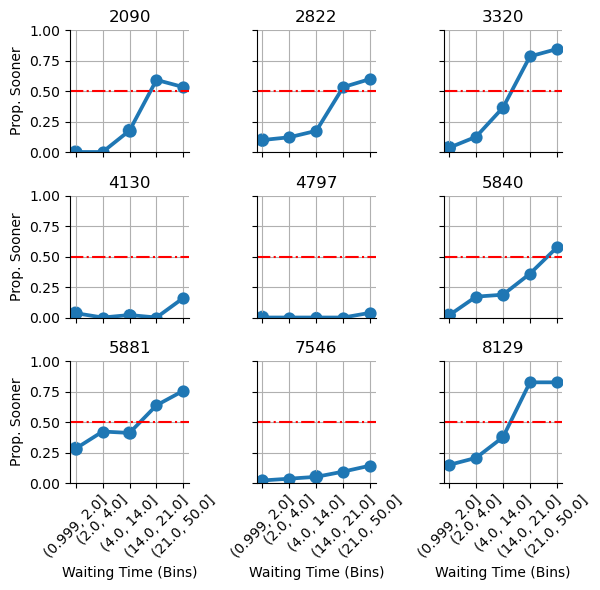

In [301]:
df_sample_tdiff = df_sooner_sid[df_sooner_sid["sid_unique"].isin(sids_sample)]

g = sns.FacetGrid(df_sample_tdiff, col = "sid_unique", col_wrap = 3, ylim=(0, 1), height=2)

g.map_dataframe(
    sns.pointplot,
    x="t-diff-bin-nr",
    y="mean"
)
g.map_dataframe(
    sns.scatterplot,
    x="t-diff-bin-nr",
    y="mean",
    size="count",
    sizes=(5, 100)
)

# Clean facet titles
for ax in g.axes.flatten():
    title = ax.get_title()
    value = title.split(" = ")[1]
    ax.set_title(value)
    ax.grid(True)
    
g.set_ylabels("Prop. Sooner")
g.set_xlabels("Waiting Time (Bins)")

# Get all axes in a flat list
axes = g.axes.flatten()

# Identify how many columns the grid has
ncols = g._ncol

# Axes belonging to the last row
last_row_axes = axes[-ncols:]

# Apply xticks only to the last row
for ax in last_row_axes:
    ax.set_xticks(ax.get_xticks())
    ax.set_xticklabels(t_labels, rotation=45)


_ = g.map(plt.axhline, y=.5, linestyle="dashdot", c="red")

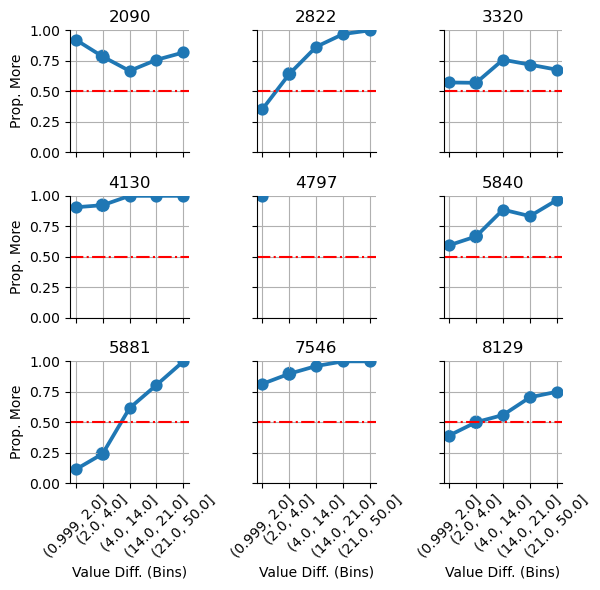

In [302]:
df_sample_valdiff = df_more_sid[df_more_sid["sid_unique"].isin(sids_sample)]
g = sns.FacetGrid(df_sample_valdiff, col = "sid_unique", col_wrap = 3, ylim=(0, 1), height=2)
g.map_dataframe(
    sns.pointplot,
    x="v-diff-bin-nr",
    y="mean",
)
g.map_dataframe(
    sns.scatterplot,
    x="v-diff-bin-nr",
    y="mean",
    size="count",
    sizes=(5, 100)
)

# Clean facet titles
for ax in g.axes.flatten():
    title = ax.get_title()
    value = title.split(" = ")[1]
    ax.set_title(value)
    ax.grid(True)
    
g.set_ylabels("Prop. More")
g.set_xlabels("Value Diff. (Bins)")

# Get all axes in a flat list
axes = g.axes.flatten()

# Identify how many columns the grid has
ncols = g._ncol

# Axes belonging to the last row
last_row_axes = axes[-ncols:]

# Apply xticks only to the last row
for ax in last_row_axes:
    ax.set_xticks(ax.get_xticks())
    ax.set_xticklabels(t_labels, rotation=45)

g.map(plt.axhline, y=.5, linestyle="dashdot", c="red")

In [105]:
import statsmodels.formula.api as smf
from scipy.stats import zscore

In [106]:
df_itc_all["r-l-v-z"] = df_itc_all[["r-l-v"]].apply(zscore)
df_itc_all["r-l-t-z"] = df_itc_all[["r-l-t"]].apply(zscore)
df_itc_all["absolute_time_diff"] = np.abs(df_itc_all["r-l-t"])
df_itc_all["relative_time_diff"] = df_itc_all["time_diff"] / ((df_itc_all["right_time"] + df_itc_all["left_time"]) / 2)

In [116]:
np.corrcoef(df_itc_all[["absolute_value_diff", "relative_value_diff", "absolute_time_diff", "relative_time_diff"]].T).round(2)

array([[ 1.  ,  0.01,  0.  ,  0.  ],
       [ 0.01,  1.  , -0.  , -0.  ],
       [ 0.  , -0.  ,  1.  ,  0.47],
       [ 0.  , -0.  ,  0.47,  1.  ]])

In [122]:
df_itc_all.to_csv("data/itc-processed.csv")

In [251]:
df_itc_t_group = df_itc_all.groupby(["sid_unique", "t-diff-bin-nr"])["sooner_picked"].mean().reset_index()
df_itc_v_group = df_itc_all.groupby(["sid_unique", "v-diff-bin-nr"])["sooner_picked"].mean().reset_index()
df_itc_t_group["t-diff-bin-nr"] = df_itc_t_group["t-diff-bin-nr"] - 2
df_itc_v_group["v-diff-bin-nr"] = df_itc_v_group["v-diff-bin-nr"] - 2

In [254]:
from sklearn.linear_model import LinearRegression

In [258]:
def change_one_subject(idx_subject):

    # time model
    df_subject_time = df_itc_t_group.query(f"""sid_unique == {idx_subject}""")
    m_t = LinearRegression()
    m_t.fit(df_subject_time[["t-diff-bin-nr"]], df_subject_time["sooner_picked"])
    t_lo_hi = np.array([m_t.intercept_ - 2*m_t.coef_, m_t.intercept_ + 2*m_t.coef_])
    t_lo_hi_rounded = t_lo_hi.round(0)
    is_t_change = (t_lo_hi_rounded[0] != t_lo_hi_rounded[1]).astype(int).item()

    # value model
    df_subject_value = df_itc_v_group.query(f"""sid_unique == {idx_subject}""")
    m_v = LinearRegression()
    m_v.fit(df_subject_value[["v-diff-bin-nr"]], df_subject_value["sooner_picked"])
    v_lo_hi = np.array([m_v.intercept_ - 2*m_v.coef_, m_v.intercept_ + 2*m_v.coef_])
    v_lo_hi_rounded = v_lo_hi.round(0)
    is_v_change = (v_lo_hi_rounded[0] != v_lo_hi_rounded[1]).astype(int).item()

    
    return idx_subject, is_t_change, is_v_change

In [290]:
l_subjects = df_itc_all["sid_unique"].drop_duplicates()#.head(100)
l_models = list(map(change_one_subject, l_subjects))

In [303]:
df_changes = pd.DataFrame(np.array(l_models), columns=["sid_unique", "Time Change", "Value Change"])
df_change_counts = df_changes[["Time Change", "Value Change"]].agg(["count", "mean"]).reset_index(drop=True).transpose()
df_change_counts = df_change_counts.reset_index()
df_change_counts.columns = ["Change Type", "Nr. Subjects", "Prop. Changes"]
df_change_counts.round(3)

,Change Type,Nr. Subjects,Prop. Changes
0,Time Change,9062.0,0.289
1,Value Change,9062.0,0.173
